In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x=pd.read_csv("Superstore.csv")
df=pd.DataFrame(x)
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [3]:
df["profit_label"]=np.where(df["Profit"]>0,"profit","loss")
#df.to_csv("superstore2.csv")
df


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,profit_label
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,profit
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,loss
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,profit
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,profit
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932,profit
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,profit


In [4]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
profit_label    0
dtype: int64

In [5]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
max_sales = df["Sales"].max()
min_sales = df["Sales"].min()

print("Total Sales:", total_sales)
print("Average Sales per Order:", avg_sales)
print("Maximum Sale Value:", max_sales)
print("Minimum Sale Value:", min_sales)

Total Sales: 2297200.8603000003
Average Sales per Order: 229.85800083049833
Maximum Sale Value: 22638.48
Minimum Sale Value: 0.444


In [7]:
print(df["Profit"].max())
print(df["Profit"].min())

8399.976
-6599.978


In [8]:
#for cat in df["Category"].unique():
    #print(cat)

df["Category"].value_counts()


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [9]:
df["Sub-Category"].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [10]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [11]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

       Segment         Category  Order_count
0     Consumer        Furniture         1113
1     Consumer  Office Supplies         3127
2     Consumer       Technology          951
3    Corporate        Furniture          646
4    Corporate  Office Supplies         1820
5    Corporate       Technology          554
6  Home Office        Furniture          362
7  Home Office  Office Supplies         1079
8  Home Office       Technology          342


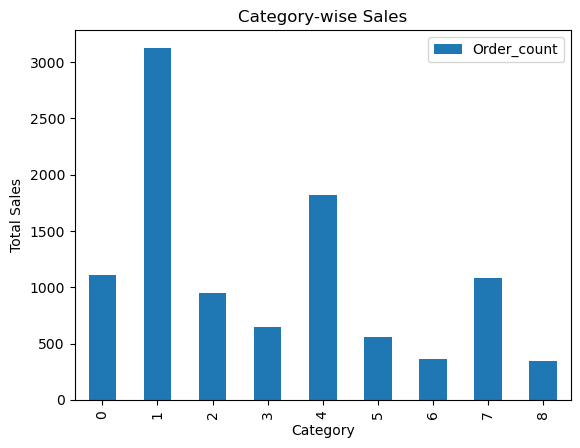

In [12]:
A1=df.groupby(["Segment","Category"]).size().reset_index(name="Order_count")
print(A1)

A1.plot(kind="bar")
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()



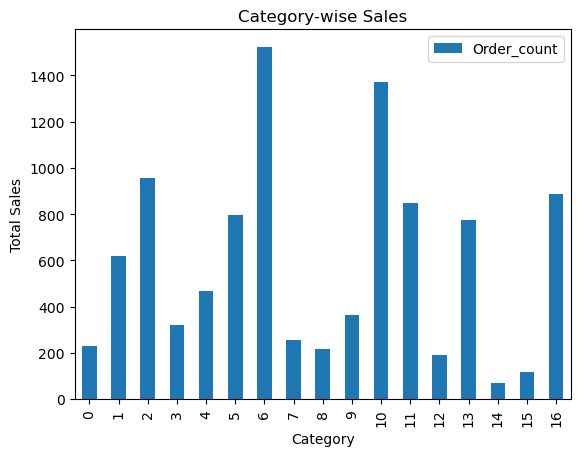

In [13]:
A2=df.groupby(["Category","Sub-Category"]).size().reset_index(name="Order_count")

A2.plot(kind="bar")
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

     Region         Category  Order_Count
0   Central        Furniture          481
1   Central  Office Supplies         1422
2   Central       Technology          420
3      East        Furniture          601
4      East  Office Supplies         1712
5      East       Technology          535
6     South        Furniture          332
7     South  Office Supplies          995
8     South       Technology          293
9      West        Furniture          707
10     West  Office Supplies         1897
11     West       Technology          599


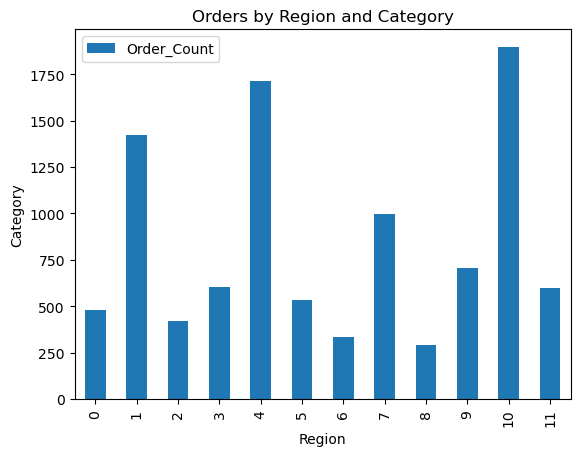

In [14]:
A3=df.groupby(["Region","Category"]).size().reset_index(name="Order_Count")
print(A3)

A3.plot(kind="bar")
plt.title("Orders by Region and Category")
plt.xlabel("Region")
plt.ylabel("Category")
plt.show()

           Category  Quantity  Order_Count
0         Furniture         1          193
1         Furniture         2          503
2         Furniture         3          534
3         Furniture         4          247
4         Furniture         5          253
5         Furniture         6          121
6         Furniture         7          115
7         Furniture         8           58
8         Furniture         9           58
9         Furniture        10           12
10        Furniture        11            8
11        Furniture        12            6
12        Furniture        13            5
13        Furniture        14            8
14  Office Supplies         1          537
15  Office Supplies         2         1461
16  Office Supplies         3         1414
17  Office Supplies         4          713
18  Office Supplies         5          752
19  Office Supplies         6          363
20  Office Supplies         7          378
21  Office Supplies         8          154
22  Office 

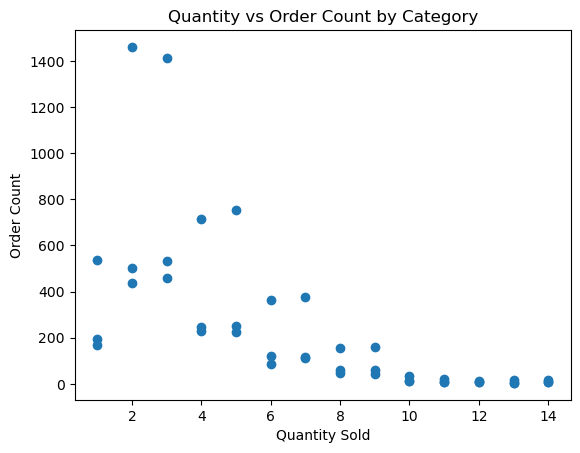

In [50]:
A4=df.groupby(["Category","Quantity"]).size().reset_index(name="Order_Count")
print(A4)

plt.scatter(A4["Quantity"], A4["Order_Count"])
plt.title("Quantity vs Order Count by Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Order Count")
plt.show()

In [16]:
#Sales Performance Label
levels = []

for sales in df["Sales"]:
    if sales > 500:
        levels.append("High Sales")
    elif sales >= 200:
        levels.append("Medium Sales")
    else:
        levels.append("Low Sales")

df["Sales_Level"] = levels
df


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,profit_label,Sales_Level
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,profit,Medium Sales
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,profit,High Sales
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,profit,Low Sales
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,loss,High Sales
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,profit,Low Sales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,profit,Low Sales
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,profit,Low Sales
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932,profit,Medium Sales
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,profit,Low Sales


In [46]:
def sales_report(data):
    print(" SALES REPORT")
    print("Total Sales:", data["Sales"].sum())
    print("Average Sales:", data["Sales"].mean())
    print("Max Sales:", data["Sales"].max())
    print("Min Sales:", data["Sales"].min())

sales_report(df)


 SALES REPORT
Total Sales: 2297200.8603000003
Average Sales: 229.85800083049833
Max Sales: 22638.48
Min Sales: 0.444


In [18]:
#Top Selling by Any Column

def top_selling(data,col,n=5):
    result=data.groupby(col)["Sales"].sum().sort_values(ascending=False).head(n)
    return result

print(top_selling(df,"Category"))
print(top_selling(df,"City",3))
print(top_selling(df,"Region"))
print(top_selling(df,"Ship Mode"))

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
Name: Sales, dtype: float64
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64
Ship Mode
Standard Class    1.358216e+06
Second Class      4.591936e+05
First Class       3.514284e+05
Same Day          1.283631e+05
Name: Sales, dtype: float64


In [19]:
#Profit Margin Analytics

def profit_margin(df):
    df["margin"]=(df["Profit"]/df["Sales"])*100
    return df[["Category","Sales","Profit","margin"]]

profit_margin(df)    
    

,Category,Sales,Profit,margin
0,Furniture,261.9600,41.9136,16.00
1,Furniture,731.9400,219.5820,30.00
2,Office Supplies,14.6200,6.8714,47.00
3,Furniture,957.5775,-383.0310,-40.00
4,Office Supplies,22.3680,2.5164,11.25
...,...,...,...,...
9989,Furniture,25.2480,4.1028,16.25
9990,Furniture,91.9600,15.6332,17.00
9991,Technology,258.5760,19.3932,7.50
9992,Office Supplies,29.6000,13.3200,45.00


In [20]:
#Loss Making Products

def loss_categories(df):
    loss=df[df["Profit"]<0].groupby("Sub-Category")["Profit"].sum()
    return loss.sort_values
loss_categories(df)    

<bound method Series.sort_values of Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64>

In [21]:
#Category Contribution %

def Category_Contribution(df):
    total=df["Sales"].sum()

    for i in df["Category"].unique():
        x=df[df["Category"]==i]["Sales"].sum()
        per=(x/total)*100
        print(i, "→", round(per,2), "%")
Category_Contribution(df)       

Furniture → 32.3 %
Office Supplies → 31.3 %
Technology → 36.4 %


In [45]:
#Bulk Order Analytics

def bulk_order(df,qty=10):
    return df[df["Quantity"]>=qty][["Category","Quantity","Sales","Profit"]]

bulk_order(df,10)    

,Category,Quantity,Sales,Profit
113,Office Supplies,14,40.096,14.5348
139,Furniture,14,43.120,20.6976
147,Technology,11,384.450,103.8015
251,Technology,13,3347.370,636.0003
329,Office Supplies,10,100.240,33.8310
...,...,...,...,...
9882,Technology,13,272.610,98.1396
9895,Technology,11,153.824,38.4560
9941,Technology,14,223.580,87.1962
9979,Office Supplies,14,437.472,153.1152


In [41]:
# Region Risk Profile
def Region_Risk(df):
    result=df.groupby("Region")[["Sales","Profit"]].sum()

    for _,r in result.iterrows():
        label="Risk" if r["Profit"]<0 else "Good"
        print(r.name, "→", label)

Region_Risk(df)

Central → Good
East → Good
South → Good
West → Good


In [24]:
#Custom Diagnostic Analytics

def diagnostic_city(df):
    res=df.groupby("City")[["Sales","Profit"]].sum()
    high_loss=res.sort_values(by="Profit").head(10)
    return high_loss
diagnostic_city(df)    

,Sales,Profit
City,,
Philadelphia,109077.0130,-13837.7674
Houston,64504.7604,-10153.5485
San Antonio,21843.5280,-7299.0502
Lancaster,9891.4640,-7239.0684
Chicago,48539.5410,-6654.5688
Burlington,21668.0820,-3622.8772
Dallas,20131.9322,-2846.5257
Phoenix,11000.2570,-2790.8832
Aurora,11656.4780,-2691.7386


In [25]:
print(df["City"].unique())

# -------- 1. CITY INPUT --------
city = input("Enter City name: ")

A1 = df[df["City"] == city]

if A1.empty:
    print("No data for this city — try another")
else:
    cats = A1["Category"].unique().tolist()
    print(cats)

    category = input("\nEnter Category from above: ")

    A2 = A1[A1["Category"] == category]
    
    print("\nSub-Category in", city, "and", category)
    subcats = A2["Sub-Category"].unique().tolist()
    print(subcats)

    sub = input("\nEnter Sub-Category from above: ")

    A3 = A2[A2["Sub-Category"] == sub]

    limit = int(input("\nEnter row limit: "))

    print("\n FINAL LIMITED DATA ")
    print(A3.head(limit))

['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood' 'Chapel Hill'
 'Morristown' 'Cincinnati' 'Inglewood' 'Tamarac' 'Colorado Springs'
 'Belleville' 'Taylor' 'Lakewood' 'Arlington' 'Arvada' 'Hackensack'
 'Saint Petersburg'

Enter City name:  Pocatello


['Furniture', 'Technology', 'Office Supplies']



Enter Category from above:  Furniture



Sub-Category in Pocatello and Furniture
['Furnishings']



Enter Sub-Category from above:  Furnishings

Enter row limit:  5



 FINAL LIMITED DATA 
         Ship Mode   Segment        Country       City  State  Postal Code  \
5670  Second Class  Consumer  United States  Pocatello  Idaho        83201   
6435   First Class  Consumer  United States  Pocatello  Idaho        83201   

     Region   Category Sub-Category   Sales  Quantity  Discount   Profit  \
5670   West  Furniture  Furnishings  355.36         4       0.0  92.3936   
6435   West  Furniture  Furnishings   35.00         4       0.0  14.7000   

     profit_label   Sales_Level  margin  
5670       profit  Medium Sales    26.0  
6435       profit     Low Sales    42.0  


In [26]:
#Product & Category Analytics

#Category Profitability Matrix

#High sales + low profit → pricing issue

#Low sales + high profit → promote this


cat_matrix = df.groupby("Category").agg({"Sales":"sum","Profit":"sum","Discount":"mean"})
print(cat_matrix)


                       Sales       Profit  Discount
Category                                           
Furniture        741999.7953   18451.2728  0.173923
Office Supplies  719047.0320  122490.8008  0.157285
Technology       836154.0330  145454.9481  0.132323


In [37]:
#Discount Danger Zone
danger = df.groupby("Discount")["Profit"].mean().reset_index(name="Danger Zone")
danger

,Discount,Danger Zone
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


In [28]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit', 'profit_label', 'Sales_Level', 'margin'],
      dtype='object')

In [29]:
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,profit_label,Sales_Level,margin
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,profit,Medium Sales,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,profit,High Sales,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,profit,Low Sales,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,loss,High Sales,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,profit,Low Sales,11.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,profit,Low Sales,16.25
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,profit,Low Sales,17.00
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932,profit,Medium Sales,7.50
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,profit,Low Sales,45.00


In [34]:
#AI ML
#Product Level Demand Model

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. Define target
y = df["Quantity"]

# 3. Select feature columns (avoid text like Country)
X = df[[
    "Sales",
    "Discount",
    "Profit",
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]].copy()


le = LabelEncoder()

X["Ship Mode"] = le.fit_transform(X["Ship Mode"])
X["Segment"] = le.fit_transform(X["Segment"])
X["Region"] = le.fit_transform(X["Region"])
X["Category"] = le.fit_transform(X["Category"])
X["Sub-Category"] = le.fit_transform(X["Sub-Category"])



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


pred = model.predict(X_test)

print("\n===== METRICS =====")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

# 7. Analytics – Feature Importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importance)



===== METRICS =====
RMSE: 1.842190905869105
MAE: 1.2946873436718358
R2: 0.3257546506980906

===== FEATURE IMPORTANCE =====
        feature  importance
0         Sales    0.421290
2        Profit    0.304318
7  Sub-Category    0.088662
5        Region    0.046569
3     Ship Mode    0.041008
4       Segment    0.038750
1      Discount    0.032600
6      Category    0.026803
